In [1]:
import numpy as np
import pandas as pd

In [2]:
breast_data = pd.read_csv('breast-cancer.csv')

In [40]:
from sklearn.pipeline import Pipeline, make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC, LinearSVC, NuSVC
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.model_selection import RandomizedSearchCV



In [4]:
breast_data = breast_data.drop('id', axis=1)
X = breast_data.drop('diagnosis', axis=1)
Y = breast_data['diagnosis']

In [5]:
X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size=0.2, random_state=42)

In [36]:
def models(X_train, y_train):
    print("Fitting SVC...")
    # Define separate parameter grids for each SVM type

    svc_params = {
        "C": [0.1, 1, 10],
        "kernel": ["rbf", "poly", "sigmoid"],
        "gamma": ["scale", "auto"],
    }
    svc = make_pipeline(StandardScaler(), RandomizedSearchCV(SVC(), svc_params, n_jobs=-1))
    svc.fit(X_train, y_train)

    linear_params = {
        "C": [0.1, 1, 10],
        "loss": ["hinge", "squared_hinge"],
        "dual": [True, False],
    }
    linearsvc = make_pipeline(
        StandardScaler(), RandomizedSearchCV(LinearSVC(), linear_params, n_jobs=-1)
    )
    linearsvc.fit(X_train, y_train)

    nusvc_params = {
        "nu": [0.25, 0.5, 0.75],
        "kernel": ["rbf", "poly", "sigmoid"],
        "gamma": ["scale", "auto"],
    }
    nusvc = make_pipeline(StandardScaler(), RandomizedSearchCV(NuSVC(), nusvc_params, n_jobs=-1))
    nusvc.fit(X_train, y_train)

    print(f"[0]: SVC train accuracy: {svc.score(X_train, y_train):.2f}")
    print(f"[1]: LinearSVC train accuracy: {linearsvc.score(X_train, y_train):.2f}")
    print(f"[2]: NuSVC train accuracy: {nusvc.score(X_train, y_train):.2f}")

    return svc, linearsvc, nusvc

In [ ]:
trained_models = models(X_train, y_train)

Fitting SVC...


/home/mush/anaconda3/lib/python3.13/site-packages/sklearn/svm/_base.py:1249: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/home/mush/anaconda3/lib/python3.13/site-packages/sklearn/svm/_base.py:1249: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/home/mush/anaconda3/lib/python3.13/site-packages/sklearn/svm/_base.py:1249: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/home/mush/anaconda3/lib/python3.13/site-packages/sklearn/svm/_base.py:1249: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/home/mush/anaconda3/lib/python3.13/site-packages/sklearn/svm/_base.py:1249: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/home/mush/anaconda3/lib/python3.13/site-packages/sklearn/svm/_base.py:1249: ConvergenceWarning: Liblinea

[0]: SVC train accuracy: 0.99
[1]: LinearSVC train accuracy: 0.99
[2]: NuSVC train accuracy: 0.98


/home/mush/anaconda3/lib/python3.13/site-packages/sklearn/model_selection/_validation.py:528: FitFailedWarning: 
10 fits failed out of a total of 50.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
10 fits failed with the following error:
Traceback (most recent call last):
  File "/home/mush/anaconda3/lib/python3.13/site-packages/sklearn/model_selection/_validation.py", line 866, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
    ~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/home/mush/anaconda3/lib/python3.13/site-packages/sklearn/base.py", line 1389, in wrapper
    return fit_method(estimator, *args, **kwargs)
  File "/home/mush/anaconda3/lib/python3.13/site-packages/sklearn/svm/_base.py", line 258, in fit


In [42]:
svc_pred = trained_models[0].predict(X_test)
linear_pred = trained_models[1].predict(X_test)
nusvc_pred = trained_models[2].predict(X_test)

svc_test_score = accuracy_score(y_test, svc_pred)
linearsvc_test_score = accuracy_score(y_test, linear_pred)
nusvc_test_score = accuracy_score(y_test, nusvc_pred)

print(f"SVC test accuracy: {svc_test_score:.2f}")
print(classification_report(y_test, svc_pred))
print(f"LinearSVC test accuracy: {linearsvc_test_score:.2f}")
print(classification_report(y_test, linear_pred))
print(f"NuSVC test accuracy: {nusvc_test_score:.2f}")
print(classification_report(y_test, nusvc_pred))

SVC test accuracy: 0.98
              precision    recall  f1-score   support

           B       0.97      1.00      0.99        71
           M       1.00      0.95      0.98        43

    accuracy                           0.98       114
   macro avg       0.99      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114

LinearSVC test accuracy: 0.97
              precision    recall  f1-score   support

           B       0.97      0.99      0.98        71
           M       0.98      0.95      0.96        43

    accuracy                           0.97       114
   macro avg       0.97      0.97      0.97       114
weighted avg       0.97      0.97      0.97       114

NuSVC test accuracy: 0.96
              precision    recall  f1-score   support

           B       0.96      0.97      0.97        71
           M       0.95      0.93      0.94        43

    accuracy                           0.96       114
   macro avg       0.96      0.95      0.95     

Exception ignored in: <function ResourceTracker.__del__ at 0x7eecc23896c0>
Traceback (most recent call last):
  File "/home/mush/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 82, in __del__
  File "/home/mush/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 91, in _stop
  File "/home/mush/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 116, in _stop_locked
ChildProcessError: [Errno 10] No child processes


In [43]:
import seaborn as sns
import matplotlib.pyplot as plt

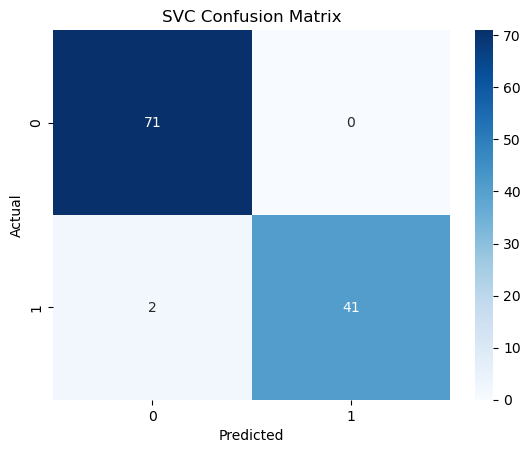

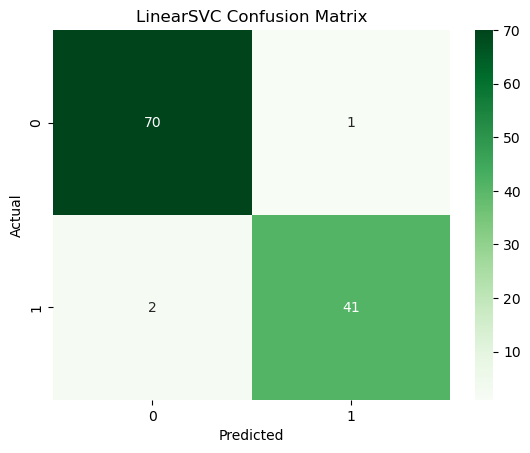

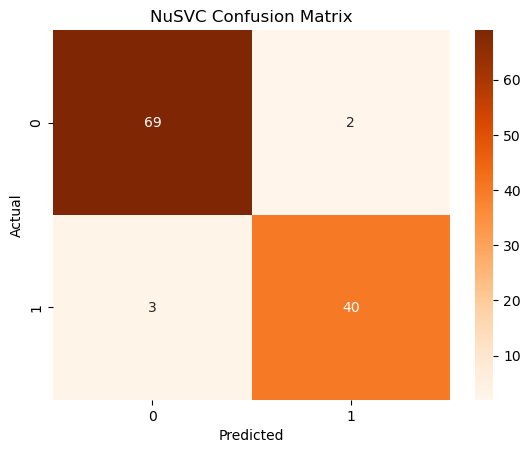

In [44]:
confusion_matrix_svc = confusion_matrix(y_test, svc_pred)
confusion_matrix_linearsvc = confusion_matrix(y_test, linear_pred)
confusion_matrix_nusvc = confusion_matrix(y_test, nusvc_pred)

sns.heatmap(confusion_matrix_svc, annot=True, fmt='d', cmap='Blues')
plt.title('SVC Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()




sns.heatmap(confusion_matrix_linearsvc, annot=True, fmt='d', cmap='Greens')
plt.title('LinearSVC Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')    
plt.show()



sns.heatmap(confusion_matrix_nusvc, annot=True, fmt='d', cmap='Oranges')
plt.title('NuSVC Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()